# Event Study Example 1

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                 1.205e+04
Date:                Mon, 01 Jun 2026   Prob (F-statistic):          2.41e-184
Time:                        12:21:37   Log-Likelihood:                -280.58
No. Observations:                 160   AIC:                             569.2
Df Residuals:                     156   BIC:                             581.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          99.7433      0.314    3

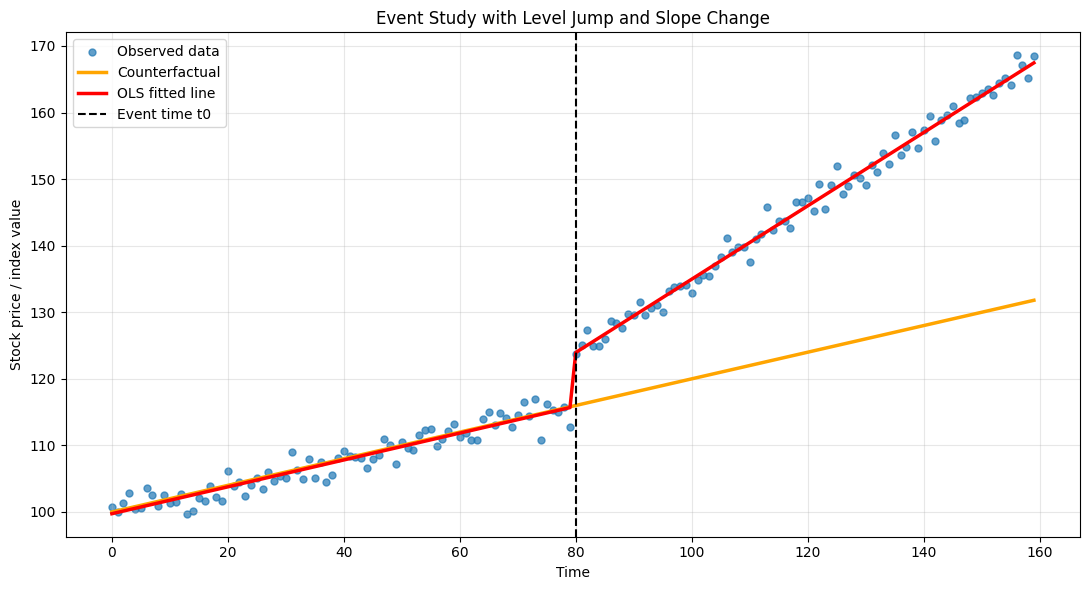

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# =========================
# User-editable parameters
# =========================
n_before = 80
n_after = 80
intercept = 100.0
slope_1 = 0.20
delta_slope = 0.35
leap = 8.0
sigma = 1.5
t0 = n_before  # treatment/event time

# =========================
# Simulate event-study data
# =========================
np.random.seed(42)

t = np.arange(n_before + n_after)
after_treatment = (t >= t0).astype(int)
t_centered = t - t0
post_time = np.maximum(t_centered, 0)  # (t - t0) * After_Treatment

# True data-generating process:
# Y = intercept + slope_1 * t + leap * After_Treatment + delta_slope * (t - t0) * After_Treatment + noise
y_true = (
    intercept
    + slope_1 * t
    + leap * after_treatment
    + delta_slope * post_time
)

noise = np.random.normal(loc=0.0, scale=sigma, size=len(t))
y = y_true + noise

df = pd.DataFrame({
    "t": t,
    "Y": y,
    "After_Treatment": after_treatment,
    "post_time": post_time
})

# =========================
# Fit event study / segmented regression
# =========================
# Equivalent to:
# Y = intercept + slope_1 * t + leap * After_Treatment + delta_slope * (t - t0) * After_Treatment + error
model = smf.ols("Y ~ t + After_Treatment + post_time", data=df).fit()

# Print full regression summary
print(model.summary())

# =========================
# Extract and print key coefficients neatly
# =========================
coef_table = pd.DataFrame({
    "coef": model.params,
    "std_err": model.bse,
    "t_value": model.tvalues,
    "p_value": model.pvalues
})

print("\nKey coefficient estimates:")
print(coef_table.loc[["Intercept", "t", "post_time", "After_Treatment"]])

# =========================
# Plot observed data and fitted values
# =========================
df["fitted"] = model.fittedvalues

plt.figure(figsize=(11, 6))
plt.scatter(df["t"], df["Y"], s=25, alpha=0.7, label="Observed data")
plt.plot(df["t"], intercept + slope_1 * df["t"], color="orange", linewidth=2.5, label="Counterfactual")
plt.plot(df["t"], df["fitted"], color="red", linewidth=2.5, label="OLS fitted line")
plt.axvline(t0, color="black", linestyle="--", linewidth=1.5, label="Event time t0")

plt.title("Event Study with Level Jump and Slope Change")
plt.xlabel("Time")
plt.ylabel("Stock price / index value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# New product + merger
# More noise

In [5]:
# t values
0.2018 / 0.007

28.82857142857143

In [ ]:
X = 0, Z = 1, Y = 2
X = 1, Z = 1, Y = 4

In [ ]:
# Counterfactuals and matching
X = 0, Z = 1, Y = 2
X = 1, Z = 1, Y = 4
Matching: assume that one of these is the counterfactual of the other
If Z = 1 for both, then they are what "would have happened" if X were the other value
X = 0, Z = 1, Y = 2
X = 1, Z = 3, Y = 10
X = 1, Z = 1, Y = ???

# Event Study 2

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.656
Model:                            OLS   Adj. R-squared:                  0.653
Method:                 Least Squares   F-statistic:                     188.2
Date:                Mon, 01 Jun 2026   Prob (F-statistic):           1.95e-46
Time:                        12:26:20   Log-Likelihood:                -541.45
No. Observations:                 200   AIC:                             1089.
Df Residuals:                     197   BIC:                             1099.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          95.2143      0.574    1

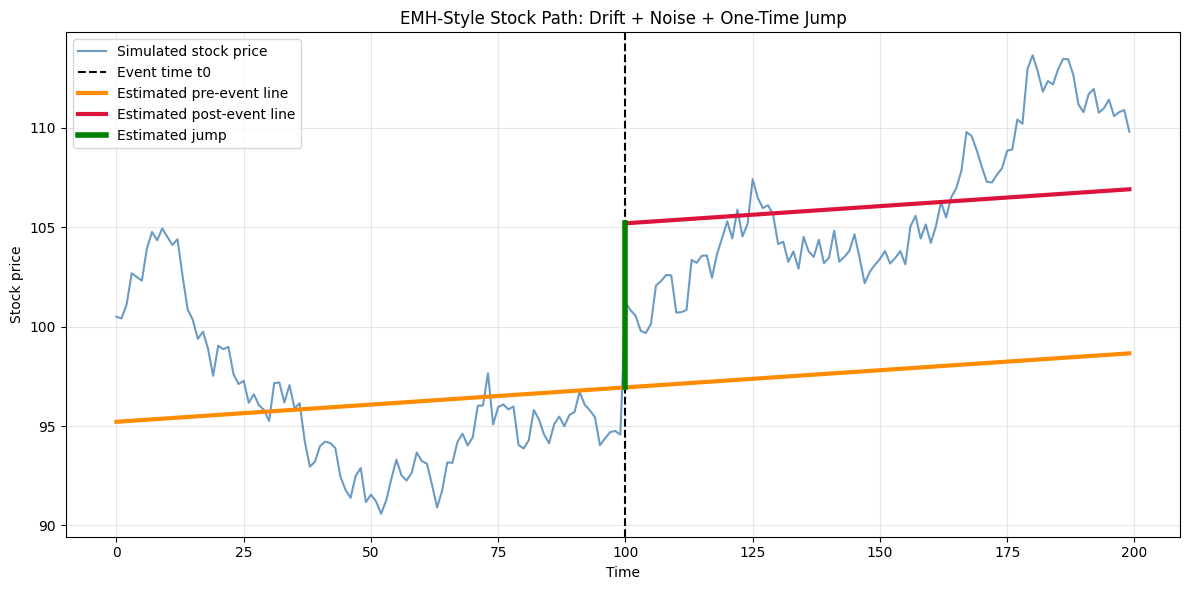

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# =========================
# User-editable parameters
# =========================
n_before = 100
n_after = 100
t0 = 100              # event time
drift = 0.05          # slow constant upward drift per time step
sigma = 1.0           # noise standard deviation
jump = 8.0            # one-time jump at the event
intercept = 100.0

# =========================
# Simulate EMH-style stock price
# =========================
# Model:
#   Y_t = intercept + drift * t + jump * 1{t >= t0} + cumulative_noise
#
# This gives:
# - a slow constant upward trend
# - zero-mean stochastic variation around that trend
# - a one-time level jump at the event
# - no slope change after the event

np.random.seed(42)

n = n_before + n_after
t = np.arange(n)
after_treatment = (t >= t0).astype(int)

# Random shocks with mean zero
eps = np.random.normal(loc=0.0, scale=sigma, size=n)

# Accumulate shocks so the price wanders around the drift line
noise_process = np.cumsum(eps)

# Price process with drift and a one-time jump
Y = intercept + drift * t + jump * after_treatment + noise_process

df = pd.DataFrame({
    "t": t,
    "Y": Y,
    "After_Treatment": after_treatment
})

# =========================
# Event study regression
# =========================
# Since there is NO slope change in the data-generating process,
# we estimate:
#   Y ~ t + After_Treatment
#
# The coefficient on After_Treatment estimates the one-time jump.
model = smf.ols("Y ~ t + After_Treatment", data=df).fit()

# Print summary table
print(model.summary())

# Print a compact coefficient table
coef_table = pd.DataFrame({
    "coef": model.params,
    "std_err": model.bse,
    "t_value": model.tvalues,
    "p_value": model.pvalues
})

print("\nKey coefficient estimates:")
print(coef_table.loc[["Intercept", "t", "After_Treatment"]])

# =========================
# Build fitted lines for plotting
# =========================
df["fitted"] = model.fittedvalues

b0 = model.params["Intercept"]
b1 = model.params["t"]
bleap = model.params["After_Treatment"]

pre = df[df["t"] < t0].copy()
post = df[df["t"] >= t0].copy()

pre_line = b0 + b1 * pre["t"]
post_line = b0 + b1 * post["t"] + bleap

# Estimated jump at the event time
y_pre_at_t0 = b0 + b1 * t0
y_post_at_t0 = b0 + b1 * t0 + bleap

# =========================
# Plot
# =========================
plt.figure(figsize=(12, 6))

plt.plot(df["t"], df["Y"], color="steelblue", linewidth=1.5, alpha=0.8, label="Simulated stock price")
plt.axvline(t0, color="black", linestyle="--", linewidth=1.5, label="Event time t0")

plt.plot(df["t"], b0 + b1 * df["t"], color="darkorange", linewidth=3, label="Estimated pre-event line")
plt.plot(post["t"], post_line, color="crimson", linewidth=3, label="Estimated post-event line")

# Show the estimated one-time jump
plt.plot([t0, t0], [y_pre_at_t0, y_post_at_t0], color="green", linewidth=4, label="Estimated jump")

plt.title("EMH-Style Stock Path: Drift + Noise + One-Time Jump")
plt.xlabel("Time")
plt.ylabel("Stock price")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# THIS IS WRONG

In [8]:
# Cumulative sum
np.cumsum([1, 1, 1, -1, 1])

array([1, 2, 3, 2, 3])

                            OLS Regression Results                            
Dep. Variable:             log_return   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     2.066
Date:                Mon, 01 Jun 2026   Prob (F-statistic):              0.152
Time:                        10:57:10   Log-Likelihood:                 628.33
No. Observations:                 199   AIC:                            -1253.
Df Residuals:                     197   BIC:                            -1246.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -0.0006      0.001     

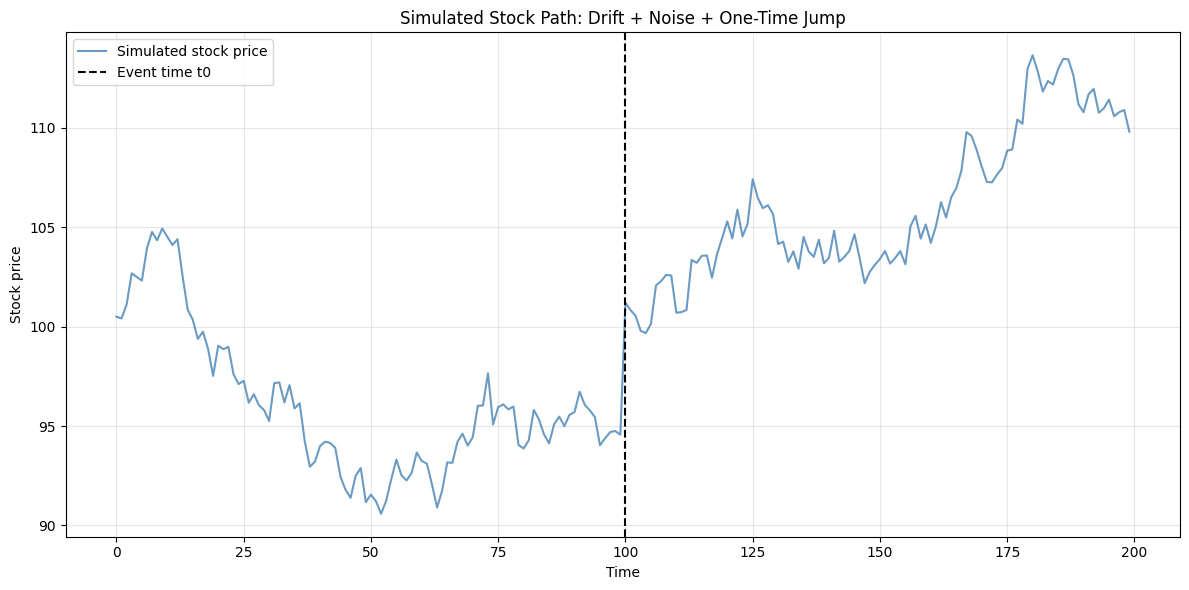

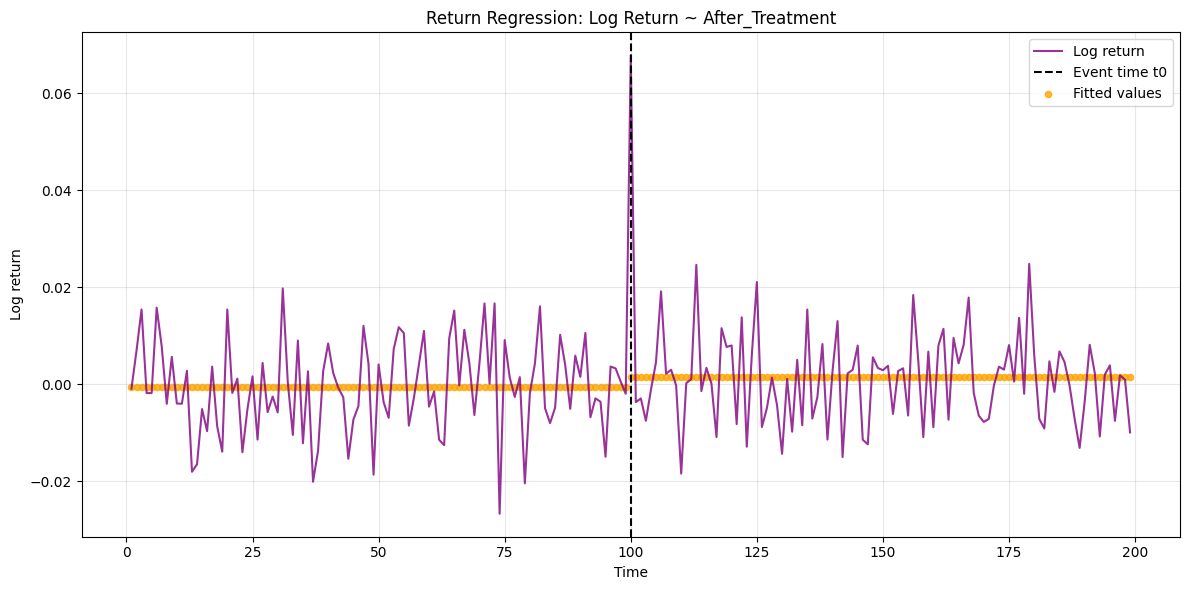

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# =========================
# User-editable parameters
# =========================
n_before = 100
n_after = 100
t0 = 100              # event time
drift = 0.05          # slow constant upward drift per time step
sigma = 1.0           # noise standard deviation
jump = 8.0            # one-time jump at the event
intercept = 100.0

# =========================
# Simulate EMH-style stock price
# =========================
# Model:
#   Y_t = intercept + drift * t + jump * 1{t >= t0} + cumulative_noise
#
# This gives:
# - a slow constant upward trend
# - zero-mean stochastic variation around that trend
# - a one-time level jump at the event
# - no slope change after the event

np.random.seed(42)

n = n_before + n_after
t = np.arange(n)
after_treatment = (t >= t0).astype(int)

# Random shocks with mean zero
eps = np.random.normal(loc=0.0, scale=sigma, size=n)

# Accumulate shocks so the price wanders around the drift line
noise_process = np.cumsum(eps)

# Price process with drift and a one-time jump
Y = intercept + drift * t + jump * after_treatment + noise_process

df = pd.DataFrame({
    "t": t,
    "Y": Y,
    "After_Treatment": after_treatment
})

# =========================
# Return construction
# =========================
# We test whether the return changes permanently after the event.
# Since the data-generating process has NO slope change after the event,
# the regression should usually find no post-event change in return.
df["log_return"] = np.log(df["Y"]).diff()

# Drop the first row because return is undefined there
df_ret = df.dropna().copy()

# =========================
# Regression: does return change after the event?
# =========================
# This tests whether the mean log return is different after the event.
# If the event only creates a one-time level jump, the coefficient should
# usually be near zero because returns return to their usual pattern after t0.
model = smf.ols("log_return ~ After_Treatment", data=df_ret).fit()

print(model.summary())

coef_table = pd.DataFrame({
    "coef": model.params,
    "std_err": model.bse,
    "t_value": model.tvalues,
    "p_value": model.pvalues
})

print("\nKey coefficient estimates:")
print(coef_table.loc[["Intercept", "After_Treatment"]])

# =========================
# Fitted values
# =========================
df_ret["fitted"] = model.fittedvalues

# =========================
# Plot price series
# =========================
plt.figure(figsize=(12, 6))
plt.plot(df["t"], df["Y"], color="steelblue", linewidth=1.5, alpha=0.8, label="Simulated stock price")
plt.axvline(t0, color="black", linestyle="--", linewidth=1.5, label="Event time t0")
plt.title("Simulated Stock Path: Drift + Noise + One-Time Jump")
plt.xlabel("Time")
plt.ylabel("Stock price")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# Plot log returns with fitted pre/post means
# =========================
plt.figure(figsize=(12, 6))

plt.plot(df_ret["t"], df_ret["log_return"], color="purple", linewidth=1.5, alpha=0.8, label="Log return")
plt.axvline(t0, color="black", linestyle="--", linewidth=1.5, label="Event time t0")

# Show fitted values
plt.scatter(df_ret["t"], df_ret["fitted"], color="orange", s=20, alpha=0.8, label="Fitted values")

plt.title("Return Regression: Log Return ~ After_Treatment")
plt.xlabel("Time")
plt.ylabel("Log return")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

                            OLS Regression Results                            
Dep. Variable:             log_return   R-squared:                       0.100
Model:                            OLS   Adj. R-squared:                  0.095
Method:                 Least Squares   F-statistic:                     21.82
Date:                Mon, 01 Jun 2026   Prob (F-statistic):           5.53e-06
Time:                        11:00:53   Log-Likelihood:                 634.92
No. Observations:                 199   AIC:                            -1266.
Df Residuals:                     197   BIC:                            -1259.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept           1.45e-05      0.00

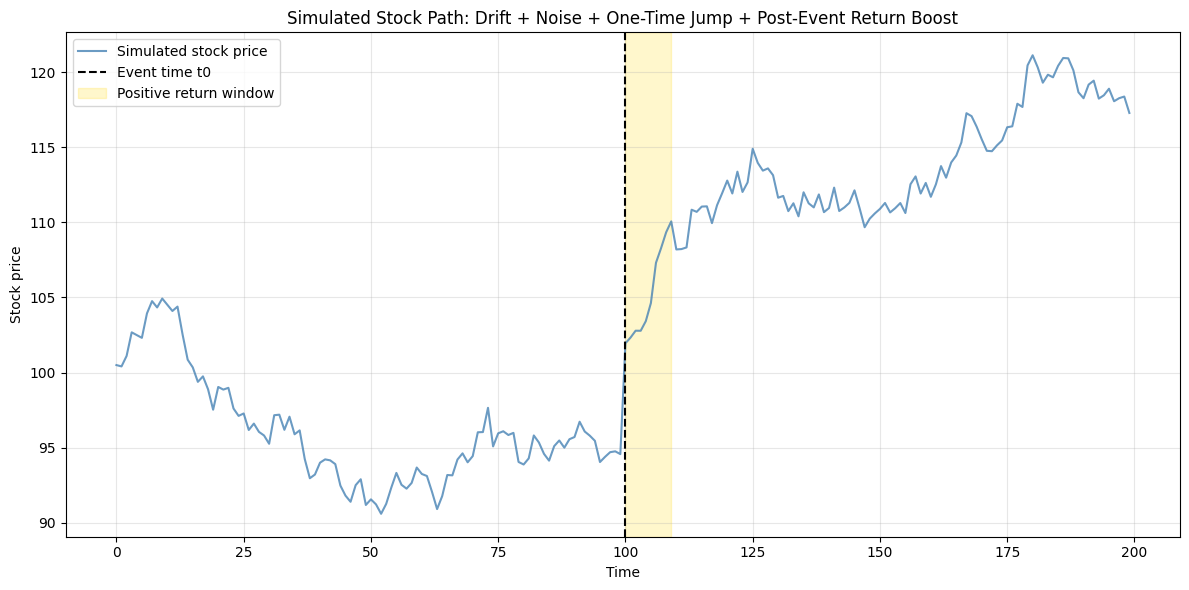

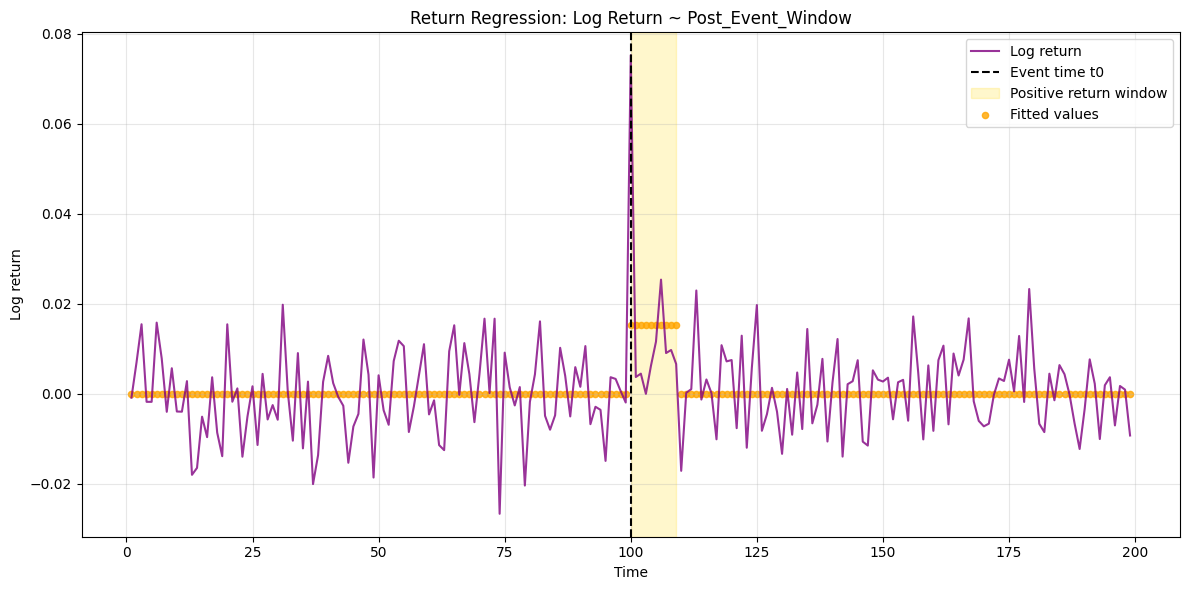

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# =========================
# User-editable parameters
# =========================
n_before = 100
n_after = 100
t0 = 100                 # event time
drift = 0.05             # baseline drift per time step
sigma = 1.0              # noise standard deviation
jump = 8.0               # one-time jump at the event
intercept = 100.0

effect_duration = 10     # number of steps the return stays elevated after the event
return_boost = 0.75      # size of the positive return effect during that window

# =========================
# Simulate stock price
# =========================
# Model:
#   Y_t = intercept + drift * t + jump * 1{t >= t0} + cumulative_noise + extra_post_event_growth
#
# The extra_post_event_growth makes the return stay higher for effect_duration steps
# after the event, instead of only creating a one-time spike.

np.random.seed(42)

n = n_before + n_after
t = np.arange(n)

# Random shocks
eps = np.random.normal(loc=0.0, scale=sigma, size=n)

# Baseline cumulative noise
noise_process = np.cumsum(eps)

# One-time level jump at the event
after_treatment = (t >= t0).astype(int)

# Positive return effect for exactly effect_duration steps after the event
post_event_window = ((t >= t0) & (t < t0 + effect_duration)).astype(int)

# Extra growth accumulates only during the post-event window
extra_post_event_growth = np.cumsum(return_boost * post_event_window)

# Price process
Y = intercept + drift * t + jump * after_treatment + extra_post_event_growth + noise_process

df = pd.DataFrame({
    "t": t,
    "Y": Y,
    "After_Treatment": after_treatment,
    "Post_Event_Window": post_event_window
})

# =========================
# Returns
# =========================
df["log_return"] = np.log(df["Y"]).diff()

# Drop first row because return is undefined there
df_ret = df.dropna().copy()

# =========================
# Regression: does return rise after the event window?
# =========================
# This tests whether mean return is higher during the post-event window.
# Since the simulated data contains a positive return boost for effect_duration steps,
# the coefficient on Post_Event_Window should usually be positive.
model = smf.ols("log_return ~ Post_Event_Window", data=df_ret).fit()

print(model.summary())

coef_table = pd.DataFrame({
    "coef": model.params,
    "std_err": model.bse,
    "t_value": model.tvalues,
    "p_value": model.pvalues
})

print("\nKey coefficient estimates:")
print(coef_table.loc[["Intercept", "Post_Event_Window"]])

# =========================
# Fitted values
# =========================
df_ret["fitted"] = model.fittedvalues

# =========================
# Plot price series
# =========================
plt.figure(figsize=(12, 6))
plt.plot(df["t"], df["Y"], color="steelblue", linewidth=1.5, alpha=0.8, label="Simulated stock price")
plt.axvline(t0, color="black", linestyle="--", linewidth=1.5, label="Event time t0")
plt.axvspan(t0, t0 + effect_duration - 1, color="gold", alpha=0.2, label="Positive return window")
plt.title("Simulated Stock Path: Drift + Noise + One-Time Jump + Post-Event Return Boost")
plt.xlabel("Time")
plt.ylabel("Stock price")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# Plot returns with fitted values
# =========================
plt.figure(figsize=(12, 6))
plt.plot(df_ret["t"], df_ret["log_return"], color="purple", linewidth=1.5, alpha=0.8, label="Log return")
plt.axvline(t0, color="black", linestyle="--", linewidth=1.5, label="Event time t0")
plt.axvspan(t0, t0 + effect_duration - 1, color="gold", alpha=0.2, label="Positive return window")
plt.scatter(df_ret["t"], df_ret["fitted"], color="orange", s=20, alpha=0.8, label="Fitted values")
plt.title("Return Regression: Log Return ~ Post_Event_Window")
plt.xlabel("Time")
plt.ylabel("Log return")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Differences-in-Differences


=== Difference-in-Differences Linear Regression Summary ===

                            OLS Regression Results                            
Dep. Variable:     accidents_per_100k   R-squared:                       0.218
Model:                            OLS   Adj. R-squared:                  0.211
Method:                 Least Squares   F-statistic:                     32.31
Date:                Mon, 01 Jun 2026   Prob (F-statistic):           1.66e-18
Time:                        11:26:36   Log-Likelihood:                -702.33
No. Observations:                 362   AIC:                             1413.
Df Residuals:                     358   BIC:                             1428.
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------

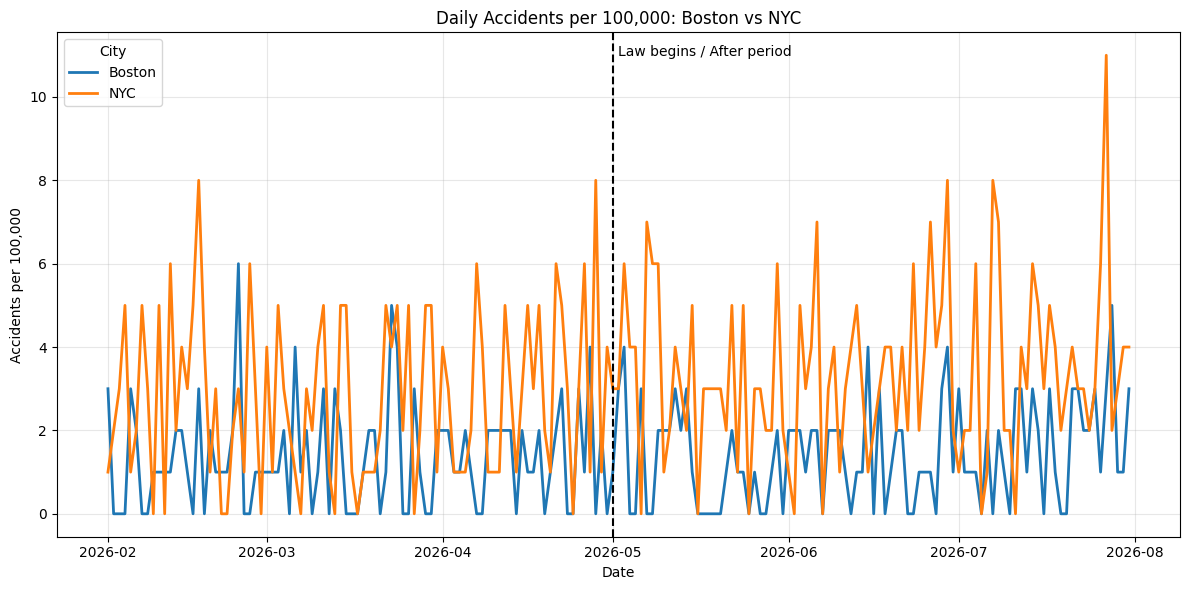


=== Sample Data ===
        date    city  treated  after  treated_after  accidents_per_100k
0 2026-02-01  Boston        1      0              0                   3
1 2026-02-02  Boston        1      0              0                   0
2 2026-02-03  Boston        1      0              0                   0
3 2026-02-04  Boston        1      0              0                   0
4 2026-02-05  Boston        1      0              0                   3
5 2026-02-06  Boston        1      0              0                   2
6 2026-02-07  Boston        1      0              0                   0
7 2026-02-08  Boston        1      0              0                   0
8 2026-02-09  Boston        1      0              0                   1
9 2026-02-10  Boston        1      0              0                   1


In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# Reproducibility
np.random.seed(42)

# ----------------------------
# Create synthetic DiD data
# ----------------------------

before_dates = pd.date_range("2026-02-01", "2026-04-30", freq="D")
after_dates = pd.date_range("2026-05-01", "2026-07-31", freq="D")

cities = ["Boston", "NYC"]

# Approximate daily accidents per 100,000 people
# 500/year -> about 1.37/day
# 1000/year -> about 2.74/day
boston_before_mean = 500 / 365
nyc_before_mean = 1000 / 365

# Summer increases accidents in both cities
summer_increase = 0.8

# Boston law reduces part of the summer increase
boston_policy_offset = -0.4

rows = []

# Before period
for city in cities:
    base_mean = boston_before_mean if city == "Boston" else nyc_before_mean
    
    for date in before_dates:
        y = np.random.poisson(lam=base_mean)
        rows.append({
            "date": date,
            "city": city,
            "treated": 1 if city == "Boston" else 0,
            "after": 0,
            "treated_after": 0,
            "accidents_per_100k": y
        })

# After period
for city in cities:
    base_mean = boston_before_mean if city == "Boston" else nyc_before_mean
    
    for date in after_dates:
        if city == "Boston":
            lam = base_mean + summer_increase + boston_policy_offset
        else:
            lam = base_mean + summer_increase
        
        lam = max(lam, 0.01)
        y = np.random.poisson(lam=lam)
        
        rows.append({
            "date": date,
            "city": city,
            "treated": 1 if city == "Boston" else 0,
            "after": 1,
            "treated_after": 1 if city == "Boston" else 0,
            "accidents_per_100k": y
        })

df = pd.DataFrame(rows)

# ----------------------------
# Fit the basic linear regression DiD model
# ----------------------------
# accidents_per_100k = beta0 + beta1*treated + beta2*after + beta3*treated_after + error
model = smf.ols(
    "accidents_per_100k ~ treated + after + treated_after",
    data=df
).fit(cov_type="HC1")

# ----------------------------
# Print results
# ----------------------------

print("\n=== Difference-in-Differences Linear Regression Summary ===\n")
print(model.summary())

print("\n=== Coefficients ===")
print(model.params)

print("\n=== Robust Standard Errors ===")
print(model.bse)

print("\n=== 95% Confidence Intervals ===")
print(model.conf_int())

# ----------------------------
# Group means for interpretation
# ----------------------------

group_means = (
    df.groupby(["city", "after"])["accidents_per_100k"]
      .agg(["mean", "std", "count"])
      .reset_index()
)

print("\n=== Group Means ===")
print(group_means)

pivot = df.pivot_table(
    values="accidents_per_100k",
    index="city",
    columns="after",
    aggfunc="mean"
)
pivot.columns = ["Before" if c == 0 else "After" for c in pivot.columns]

print("\n=== Mean Accidents per 100k by City and Period ===")
print(pivot)

# ----------------------------
# Manual DiD calculation
# ----------------------------

boston_before = df[(df["city"] == "Boston") & (df["after"] == 0)]["accidents_per_100k"].mean()
boston_after = df[(df["city"] == "Boston") & (df["after"] == 1)]["accidents_per_100k"].mean()
nyc_before = df[(df["city"] == "NYC") & (df["after"] == 0)]["accidents_per_100k"].mean()
nyc_after = df[(df["city"] == "NYC") & (df["after"] == 1)]["accidents_per_100k"].mean()

did = (boston_after - boston_before) - (nyc_after - nyc_before)

print("\n=== Manual Difference-in-Differences Calculation ===")
print(f"Boston before: {boston_before:.4f}")
print(f"Boston after:  {boston_after:.4f}")
print(f"NYC before:    {nyc_before:.4f}")
print(f"NYC after:     {nyc_after:.4f}")
print(f"Boston change: {boston_after - boston_before:.4f}")
print(f"NYC change:    {nyc_after - nyc_before:.4f}")
print(f"DiD estimate:  {did:.4f}")

print("\n=== Interpretation ===")
print(f"Intercept (beta0): {model.params['Intercept']:.4f}")
print(f"Treated (beta1): {model.params['treated']:.4f}")
print(f"After (beta2): {model.params['after']:.4f}")
print(f"Treated x After (beta3, DiD effect): {model.params['treated_after']:.4f}")

# ----------------------------
# Plot with Boston and NYC labels
# ----------------------------

plot_df = (
    df.groupby(["date", "city"], as_index=False)["accidents_per_100k"]
      .mean()
)

plt.figure(figsize=(12, 6))

for city, color in [("Boston", "tab:blue"), ("NYC", "tab:orange")]:
    sub = plot_df[plot_df["city"] == city]
    plt.plot(sub["date"], sub["accidents_per_100k"], label=city, color=color, linewidth=2)

plt.axvline(pd.Timestamp("2026-05-01"), color="black", linestyle="--", linewidth=1.5)
plt.text(pd.Timestamp("2026-05-02"), plt.ylim()[1] * 0.95, "Law begins / After period", fontsize=10)

plt.title("Daily Accidents per 100,000: Boston vs NYC")
plt.xlabel("Date")
plt.ylabel("Accidents per 100,000")
plt.legend(title="City")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ----------------------------
# Sample rows
# ----------------------------

print("\n=== Sample Data ===")
print(df.head(10))